# E-Commerce Sales & Customer Analytics

## Project Overview

This project analyzes e-commerce sales data to understand sales performance, customer behavior, product performance, geographical trends, sales channels, discounts, and payment methods.

The analysis is performed using Python, Pandas, NumPy, and Matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Dataset

In [2]:
df = pd.read_csv("../data/ecommerce_sales.csv")

In [3]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,City,State,Category,Product,Quantity,Unit_Price,Discount_Percent,Payment_Method,Sales_Channel,Customer_Rating,Gross_Sales,Net_Sales
0,ORD10001,2025-09-06,CUST0770,Aman Verma,Female,34,Ahmedabad,Gujarat,Beauty,Perfume,2,1599,10,Debit Card,Online,4.7,3198,2878.20
1,ORD10002,2024-09-09,CUST0700,Pooja Mehta,Female,32,Pune,Maharashtra,Electronics,Wireless Headphones,2,2499,10,UPI,Online,3.7,4998,4498.20
2,ORD10003,2025-10-08,CUST0777,Priya Gupta,Male,29,Nagpur,Maharashtra,Fashion,Backpack,1,1799,15,Net Banking,Online,4.0,1799,1529.15
3,ORD10004,2024-02-04,CUST0566,Priya Singh,Female,21,Pune,Maharashtra,Fashion,Jeans,2,1999,10,Debit Card,Online,3.7,3998,3598.20
4,ORD10005,2024-09-26,CUST0217,Sneha Joshi,Male,22,Chennai,Tamil Nadu,Electronics,Smart Watch,3,3999,20,UPI,Offline,3.0,11997,9597.60


## 2. Data Understanding

In [4]:
df.shape

(8020, 18)

In [5]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender',
       'Age', 'City', 'State', 'Category', 'Product', 'Quantity', 'Unit_Price',
       'Discount_Percent', 'Payment_Method', 'Sales_Channel',
       'Customer_Rating', 'Gross_Sales', 'Net_Sales'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8020 entries, 0 to 8019
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          8020 non-null   str    
 1   Order_Date        8020 non-null   str    
 2   Customer_ID       8020 non-null   str    
 3   Customer_Name     8020 non-null   str    
 4   Gender            8020 non-null   str    
 5   Age               8020 non-null   int64  
 6   City              8020 non-null   str    
 7   State             8020 non-null   str    
 8   Category          8020 non-null   str    
 9   Product           8020 non-null   str    
 10  Quantity          8020 non-null   int64  
 11  Unit_Price        8020 non-null   int64  
 12  Discount_Percent  8020 non-null   int64  
 13  Payment_Method    8000 non-null   str    
 14  Sales_Channel     8020 non-null   str    
 15  Customer_Rating   8000 non-null   float64
 16  Gross_Sales       8020 non-null   int64  
 17  Net_Sa

In [7]:
df.isnull().sum()

Order_ID             0
Order_Date           0
Customer_ID          0
Customer_Name        0
Gender               0
Age                  0
City                 0
State                0
Category             0
Product              0
Quantity             0
Unit_Price           0
Discount_Percent     0
Payment_Method      20
Sales_Channel        0
Customer_Rating     20
Gross_Sales          0
Net_Sales            0
dtype: int64

## 3. Data Cleaning

In [8]:
df.duplicated().sum()

np.int64(20)

In [9]:
df = df.drop_duplicates()

In [10]:
df.isnull().sum()

Order_ID             0
Order_Date           0
Customer_ID          0
Customer_Name        0
Gender               0
Age                  0
City                 0
State                0
Category             0
Product              0
Quantity             0
Unit_Price           0
Discount_Percent     0
Payment_Method      20
Sales_Channel        0
Customer_Rating     20
Gross_Sales          0
Net_Sales            0
dtype: int64

In [11]:
df["Payment_Method"] = df["Payment_Method"].fillna("Unknown")

In [12]:
df["Payment_Method"].isnull().sum()

np.int64(0)

In [13]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [14]:
df["Order_Date"].dtype

dtype('<M8[us]')

In [15]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate Rows:", df.duplicated().sum())
print("\nMissing Values:")
print(df.isnull().sum())

Rows: 8000
Columns: 18
Duplicate Rows: 0

Missing Values:
Order_ID             0
Order_Date           0
Customer_ID          0
Customer_Name        0
Gender               0
Age                  0
City                 0
State                0
Category             0
Product              0
Quantity             0
Unit_Price           0
Discount_Percent     0
Payment_Method       0
Sales_Channel        0
Customer_Rating     20
Gross_Sales          0
Net_Sales            0
dtype: int64


## 4. Exploratory Data Analysis

### 4.1 Overall Sales Performance

In [16]:
total_sales = df["Net_Sales"].sum()
print("Total Net Sales:", total_sales)

Total Net Sales: 35037553.449999996


In [17]:
total_orders = df["Order_ID"].nunique()
print("Total Orders:", total_orders)

Total Orders: 8000


In [18]:
total_customers = df["Customer_ID"].nunique()
print("Total Customers:", total_customers)

Total Customers: 1490


In [19]:
aov = total_sales / total_orders
print("Average Order Value:", round(aov, 2))

Average Order Value: 4379.69


### 4.2 Category Analysis

In [20]:
category_sales = (
    df.groupby("Category")["Net_Sales"]
      .sum()
      .sort_values(ascending=False)
)
print(category_sales)

Category
Electronics       11530921.70
Home & Kitchen    10503470.25
Fashion            6349002.20
Sports             4202201.35
Beauty             2451957.95
Name: Net_Sales, dtype: float64


In [21]:
category_quantity = (
    df.groupby("Category")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)
print(category_quantity)

Category
Electronics       4594
Fashion           3342
Home & Kitchen    3048
Sports            2210
Beauty            1962
Name: Quantity, dtype: int64


In [22]:
category_price = (
    df.groupby("Category")["Unit_Price"]
      .mean()
      .sort_values(ascending=False)
)
print(category_price.round(2))

Category
Home & Kitchen    3797.86
Electronics       2773.52
Fashion           2114.18
Sports            2104.43
Beauty            1396.54
Name: Unit_Price, dtype: float64


### 4.3 Customer Analysis

In [23]:
orders_per_customer = (
    df.groupby("Customer_ID")["Order_ID"]
      .nunique()
      .sort_values(ascending=False)
)
print(orders_per_customer.head(10))

Customer_ID
CUST1361    15
CUST0763    13
CUST1177    13
CUST0856    13
CUST1405    13
CUST0874    13
CUST0656    13
CUST1471    12
CUST1330    12
CUST0430    12
Name: Order_ID, dtype: int64


In [24]:
repeat_customers = orders_per_customer[orders_per_customer > 1]
print("Repeat Customers:", repeat_customers.count())

Repeat Customers: 1459


In [25]:
repeat_customer_rate = (
    repeat_customers.count()
    / total_customers
) * 100
print(
    "Repeat Customer Rate:",
    round(repeat_customer_rate, 2),
    "%"
)           

Repeat Customer Rate: 97.92 %


In [26]:
order_frequency = (
    orders_per_customer
    .value_counts()
    .sort_index()
)
print(order_frequency)

Order_ID
1      31
2      98
3     201
4     254
5     238
6     248
7     166
8     119
9      55
10     42
11     18
12     13
13      6
15      1
Name: count, dtype: int64


### 4.4 Geographical Analysis

In [27]:
state_sales = (
    df.groupby("State")["Net_Sales"]
      .sum()
      .sort_values(ascending=False)
)
print(state_sales)

State
Maharashtra      8968936.40
Gujarat          5571879.45
Rajasthan        3027989.50
Tamil Nadu       3012991.30
West Bengal      2984435.70
Karnataka        2908413.75
Delhi            2898557.80
Uttar Pradesh    2885750.25
Telangana        2778599.30
Name: Net_Sales, dtype: float64


In [28]:
state_share = (
    state_sales / total_sales
) * 100
print(state_share.round(2))

State
Maharashtra      25.60
Gujarat          15.90
Rajasthan         8.64
Tamil Nadu        8.60
West Bengal       8.52
Karnataka         8.30
Delhi             8.27
Uttar Pradesh     8.24
Telangana         7.93
Name: Net_Sales, dtype: float64


In [29]:
top_state = state_sales.idxmax()
top_state_sales = state_sales.max()
print("Top State:", top_state)
print("Top State Revenue:", round(top_state_sales, 2))

Top State: Maharashtra
Top State Revenue: 8968936.4


### 4.5 Sales Channel Analysis

In [30]:
channel_orders = (
    df.groupby("Sales_Channel")["Order_ID"]
      .nunique()
)
print(channel_orders)

Sales_Channel
Offline    2585
Online     5415
Name: Order_ID, dtype: int64


In [31]:
channel_sales = (
    df.groupby("Sales_Channel")["Net_Sales"]
      .sum()
)
print(channel_sales)

Sales_Channel
Offline    11235420.90
Online     23802132.55
Name: Net_Sales, dtype: float64


In [32]:
channel_aov = channel_sales / channel_orders
print(channel_aov.round(2))

Sales_Channel
Offline    4346.39
Online     4395.59
dtype: float64


In [33]:
channel_share = (
    channel_sales / total_sales
) * 100
print(channel_share.round(2))

Sales_Channel
Offline    32.07
Online     67.93
Name: Net_Sales, dtype: float64


### 4.6 Time-Based Analysis

In [34]:
df["Month"] = df["Order_Date"].dt.to_period("M")

In [35]:
df[["Order_Date", "Month"]].head()

,Order_Date,Month
0,2025-09-06,2025-09
1,2024-09-09,2024-09
2,2025-10-08,2025-10
3,2024-02-04,2024-02
4,2024-09-26,2024-09


In [36]:
monthly_sales = (
    df.groupby("Month")["Net_Sales"]
      .sum()
)
print(monthly_sales)

Month
2024-01    1363702.65
2024-02    1356785.20
2024-03    1441602.25
2024-04    1283272.55
2024-05    1566371.70
2024-06    1427552.70
2024-07    1583889.75
2024-08    1443705.05
2024-09    1425501.80
2024-10    1569897.75
2024-11    1498596.95
2024-12    1612598.40
2025-01    1554032.45
2025-02    1293934.85
2025-03    1592901.10
2025-04    1364198.85
2025-05    1456381.70
2025-06    1231748.60
2025-07    1507549.95
2025-08    1497502.45
2025-09    1384006.85
2025-10    1596791.15
2025-11    1448421.20
2025-12    1536607.55
Freq: M, Name: Net_Sales, dtype: float64


In [37]:
monthly_orders = (
    df.groupby("Month")["Order_ID"]
      .nunique()
)
print(monthly_orders)

Month
2024-01    334
2024-02    329
2024-03    327
2024-04    297
2024-05    373
2024-06    303
2024-07    332
2024-08    338
2024-09    325
2024-10    354
2024-11    317
2024-12    379
2025-01    351
2025-02    295
2025-03    343
2025-04    302
2025-05    334
2025-06    307
2025-07    351
2025-08    340
2025-09    323
2025-10    369
2025-11    328
2025-12    349
Freq: M, Name: Order_ID, dtype: int64


In [38]:
df["Year"] = df["Order_Date"].dt.year

In [39]:
yearly_sales = (
    df.groupby("Year")["Net_Sales"]
      .sum()
)
print("Yearly Revenue:")
print(yearly_sales)

Yearly Revenue:
Year
2024    17573476.75
2025    17464076.70
Name: Net_Sales, dtype: float64


In [40]:
yearly_orders = (
    df.groupby("Year")["Order_ID"]
      .nunique()
)
print("Yearly Orders:")
print(yearly_orders)

Yearly Orders:
Year
2024    4008
2025    3992
Name: Order_ID, dtype: int64


In [41]:
yearly_aov = yearly_sales / yearly_orders

print("Yearly AOV:")
print(yearly_aov.round(2))

Yearly AOV:
Year
2024    4384.60
2025    4374.77
dtype: float64


In [42]:
revenue_growth = (
    (yearly_sales[2025] - yearly_sales[2024])
    / yearly_sales[2024]
) * 100
print("Revenue YoY Growth:", round(revenue_growth, 2), "%")

Revenue YoY Growth: -0.62 %


In [43]:
order_growth = (
    (yearly_orders[2025] - yearly_orders[2024])
    / yearly_orders[2024]
) * 100
print("Order YoY Growth:", round(order_growth, 2), "%")

Order YoY Growth: -0.4 %


In [44]:
aov_growth = (
    (yearly_aov[2025] - yearly_aov[2024])
    / yearly_aov[2024]
) * 100
print("AOV YoY Growth:", round(aov_growth, 2), "%")

AOV YoY Growth: -0.22 %


### 4.7 Product Analysis

In [45]:
top_products_revenue = (
    df.groupby("Product")["Net_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print("Top 10 Products by Revenue:")
print(top_products_revenue)

Top 10 Products by Revenue:
Product
Smart Watch            4272731.55
Air Fryer              4004921.70
Bluetooth Speaker      3303698.40
Coffee Maker           2997908.65
Running Shoes          2479723.15
Wireless Headphones    2453018.40
Mixer Grinder          2297918.45
Cricket Bat            1800585.40
Jeans                  1515042.10
Power Bank             1501473.35
Name: Net_Sales, dtype: float64


In [46]:
top_products_quantity = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print("Top 10 Products by Quantity:")
print(top_products_quantity)

Top 10 Products by Quantity:
Product
Bluetooth Speaker      1216
Smart Watch            1185
Power Bank             1106
Wireless Headphones    1087
Running Shoes           919
Jeans                   845
Backpack                813
Air Fryer               799
Mixer Grinder           769
Casual Shirt            765
Name: Quantity, dtype: int64


### 4.8 Discount Analysis

In [47]:
discount_sales = (
    df.groupby("Discount_Percent")["Net_Sales"]
      .sum()
)
discount_orders = (
    df.groupby("Discount_Percent")["Order_ID"]
      .nunique()
)

In [48]:
discount_aov = discount_sales / discount_orders
print("AOV by Discount:")
print(discount_aov.round(2))

AOV by Discount:
Discount_Percent
0     4812.76
5     4666.26
10    4368.63
15    4034.04
20    3982.84
25    3512.77
dtype: float64


### 4.9 Customer Rating Analysis

In [49]:
category_rating = (
    df.groupby("Category")["Customer_Rating"]
      .mean()
      .sort_values(ascending=False)
)
print("Average Customer Rating by Category:")
print(category_rating.round(2))

Average Customer Rating by Category:
Category
Beauty            4.02
Fashion           3.99
Home & Kitchen    3.98
Electronics       3.97
Sports            3.97
Name: Customer_Rating, dtype: float64


### 4.10 Payment Method Analysis

In [50]:
payment_orders = (
    df.groupby("Payment_Method")["Order_ID"]
      .nunique()
      .sort_values(ascending=False)
)
print("Orders by Payment Method:")
print(payment_orders)

Orders by Payment Method:
Payment_Method
UPI            3253
Credit Card    1886
Debit Card     1434
Net Banking     783
Cash            624
Unknown          20
Name: Order_ID, dtype: int64


In [51]:
payment_sales = (
    df.groupby("Payment_Method")["Net_Sales"]
      .sum()
      .sort_values(ascending=False)
)
print("Revenue by Payment Method:")
print(payment_sales)

Revenue by Payment Method:
Payment_Method
UPI            14380254.15
Credit Card     8082385.00
Debit Card      6249317.10
Net Banking     3470556.75
Cash            2769055.50
Unknown           85984.95
Name: Net_Sales, dtype: float64


## 5. Data Visualization

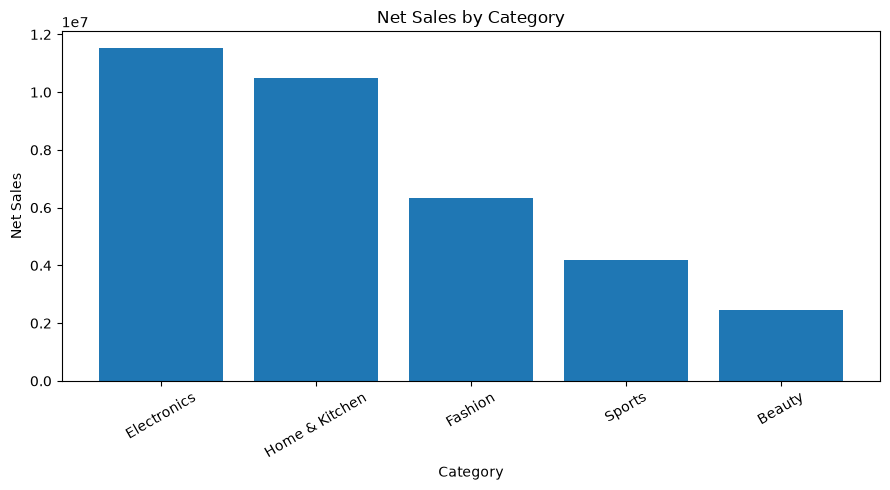

In [52]:
plt.figure(figsize=(9, 5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Net Sales by Category")
plt.xlabel("Category")
plt.ylabel("Net Sales")

plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../visualizations/revenue_by_category.png", dpi=300)
plt.show()

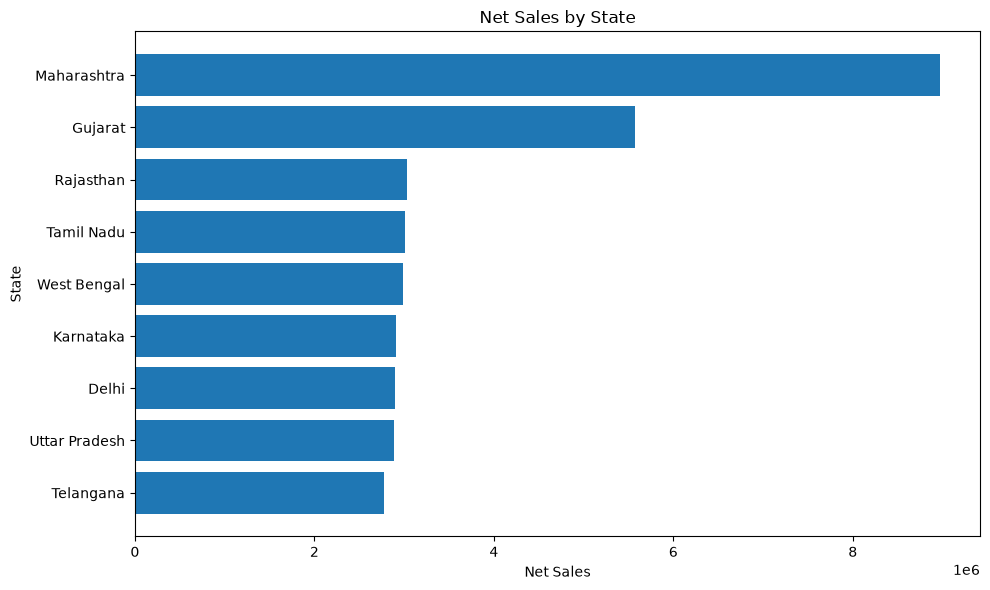

In [53]:
plt.figure(figsize=(10, 6))

plt.barh(state_sales.index, state_sales.values)

plt.title("Net Sales by State")
plt.xlabel("Net Sales")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("../visualizations/revenue_by_state.png", dpi=300)
plt.show()

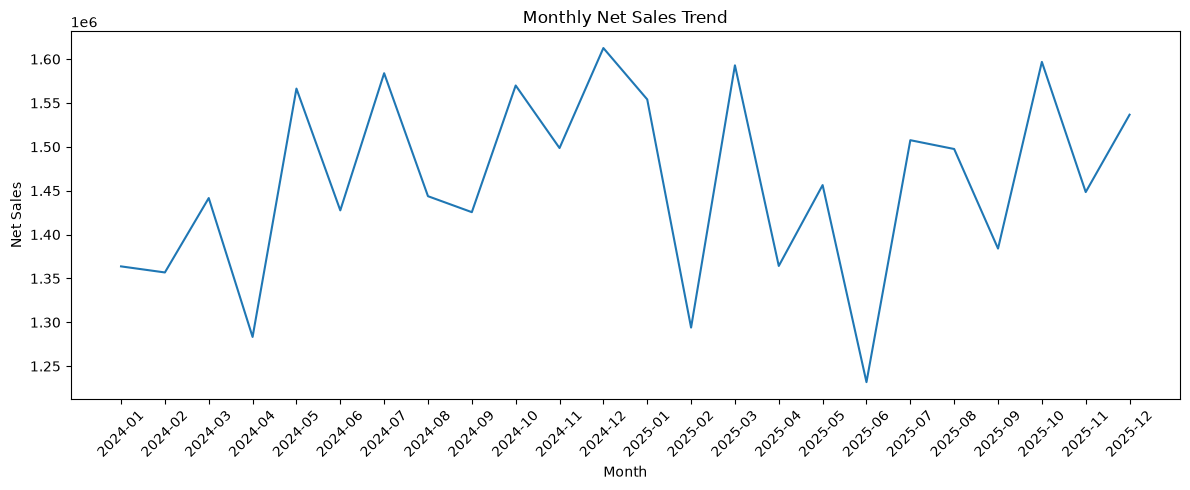

In [54]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

plt.title("Monthly Net Sales Trend")
plt.xlabel("Month")
plt.ylabel("Net Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../visualizations/monthly_sales_trend.png", dpi=300)
plt.show()

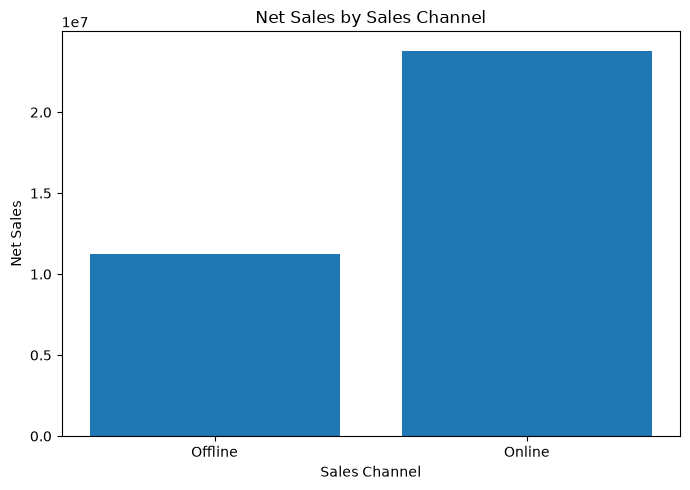

In [55]:
plt.figure(figsize=(7, 5))

plt.bar(
    channel_sales.index,
    channel_sales.values
)

plt.title("Net Sales by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Net Sales")

plt.tight_layout()
plt.savefig("../visualizations/revenue_by_channel.png", dpi=300)
plt.show()

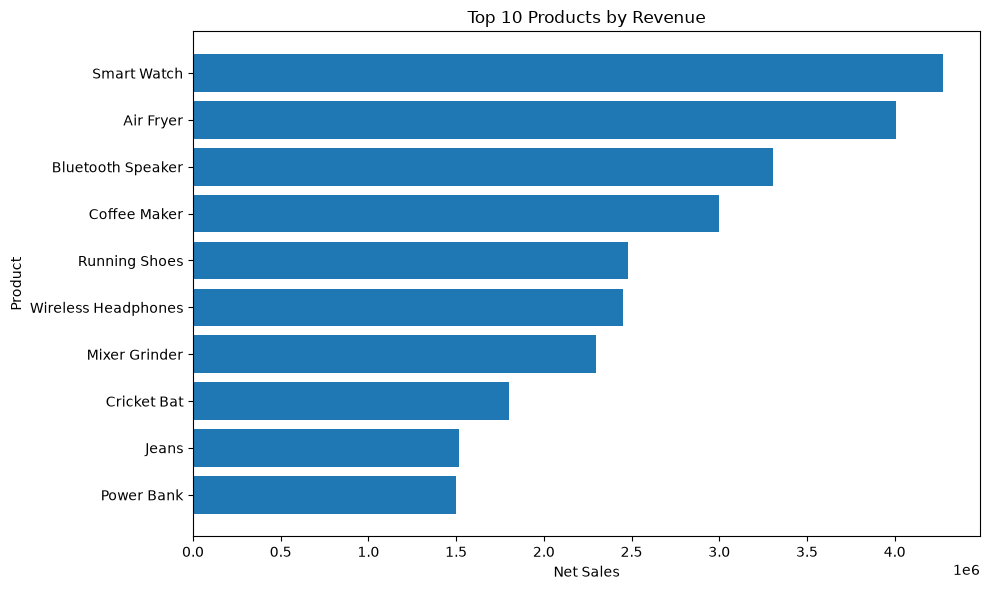

In [56]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products_revenue.index,
    top_products_revenue.values
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Net Sales")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("../visualizations/top_products_by_revenue.png", dpi=300)
plt.show()

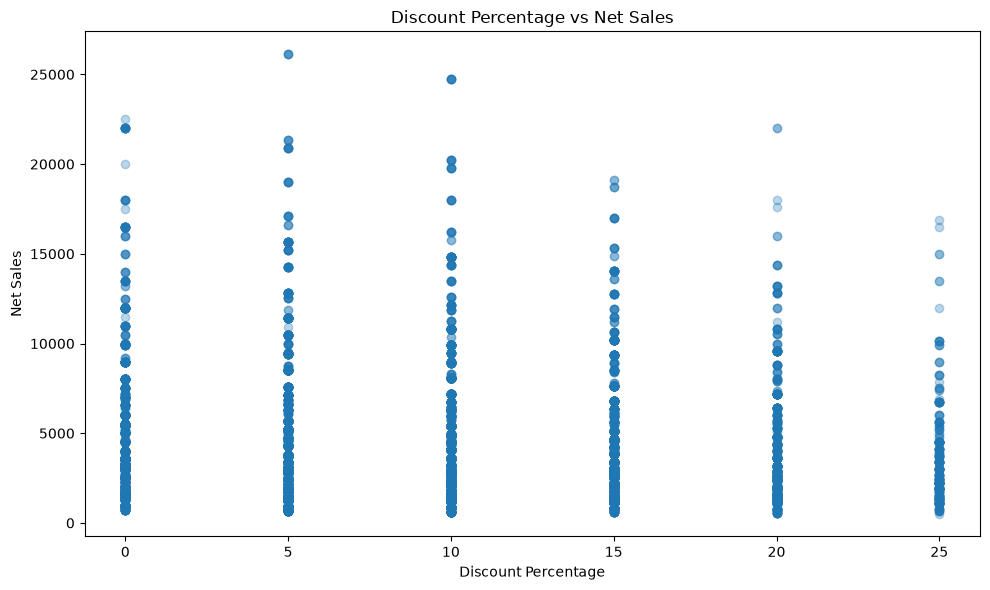

In [57]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Percent"],
    df["Net_Sales"],
    alpha=0.3
)

plt.title("Discount Percentage vs Net Sales")
plt.xlabel("Discount Percentage")
plt.ylabel("Net Sales")

plt.tight_layout()
plt.savefig("../visualizations/discount_vs_sales.png", dpi=300)
plt.show()

## 6. Key Business Insights

### Key Business Insights

1. **Strong overall sales performance:** The business generated approximately ₹3.51 crore in net sales across 8,000 orders, with an average order value of approximately ₹4,388.72.

2. **High customer repeat rate:** 1,459 out of 1,490 customers were repeat customers, resulting in a repeat customer rate of approximately 97.92%.

3. **Electronics leads revenue generation:** Electronics was the highest-performing category, generating approximately ₹1.16 crore in net sales.

4. **Maharashtra is the largest market:** Maharashtra generated approximately ₹89.85 lakh and contributed around 25.59% of total net sales.

5. **Online is the dominant sales channel:** Online generated 5,415 orders compared with 2,585 offline orders.

6. **Smart Watch is the leading product:** Smart Watch generated approximately ₹42.77 lakh in net sales, making it the highest-revenue product.

7. **Higher discounts are associated with lower AOV:** Average order value decreased from approximately ₹4,821 at 0% discount to ₹3,516.90 at 25% discount.

8. **2025 performance remained broadly stable:** Revenue declined by only 0.64% YoY, while orders declined by 0.40% and AOV declined by 0.24%.

## 7. Business Recommendations

### Recommendations

1. **Prioritize high-performing categories:** Continue investing in Electronics and Home & Kitchen while identifying opportunities to improve lower-performing categories.

2. **Strengthen the online channel:** Since Online accounts for the majority of orders, the business should continue improving the online customer experience, conversion, and retention strategy.

3. **Focus on Maharashtra while expanding other markets:** Maharashtra is a major revenue contributor, but the business should evaluate opportunities to increase penetration in lower-contributing states and reduce geographic concentration.

4. **Optimize discount strategy:** The observed relationship between higher discounts and lower AOV suggests that discounting should be targeted rather than applied broadly. Promotional campaigns should be evaluated based on incremental revenue and profitability.

5. **Leverage high-performing products:** Products such as Smart Watches, Air Fryers, and Bluetooth Speakers should be evaluated for cross-selling, bundling, and inventory prioritization.

6. **Protect customer retention:** The very high repeat-customer rate indicates strong repeat purchasing behavior. Loyalty programs and personalized offers could help maintain this customer base.

7. **Monitor stagnant growth:** Since 2025 revenue was broadly flat versus 2024, management should investigate category, product, geographic, and channel-level changes to identify opportunities for renewed growth.

## 8. Conclusion

This analysis provides an overview of e-commerce sales performance across customers, products, categories, geography, sales channels, discounts, and payment methods.

The business generated approximately ₹3.51 crore in net sales and demonstrated a strong repeat-customer rate of 97.92%. Electronics was the leading category, Maharashtra was the largest geographic market, and Online was the dominant sales channel.

Year-over-year performance remained broadly stable, with a marginal decline in revenue of 0.64% in 2025. The analysis also indicates that higher discount levels were associated with lower average order values.

Overall, the findings highlight opportunities to strengthen the online channel, optimize discounting, leverage high-performing products, and expand growth across underpenetrated markets.